# 6CS012 - Part II: Animals Image Classification
### CNN from Scratch and ResNet50 Transfer Learning

**Dataset:** Animals-10 Enhanced Dataset  
**Framework:** TensorFlow Keras, NumPy, Matplotlib and scikit-learn


## Section 0 - Setup and Imports

This notebook follows the Part II Vision Task requirements. It keeps the code simple and close to the Week 1-7 materials: Keras CNN layers, Batch Normalization, Dropout, Adam, SGD, transfer learning, Matplotlib plots and scikit-learn evaluation metrics.


In [1]:
import os
import time
import warnings
from pathlib import Path

from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings("ignore")
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))


2026-05-10 06:03:44.998421: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778393025.251376      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778393025.329619      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778393025.864638      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778393025.864681      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778393025.864684      57 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


---
## Section 1 - Data Understanding, Analysis and Visualization

The dataset contains images of 10 animal classes. The folders are already split into training, validation and testing sets, so the test data is not used while training the models.


In [2]:
# Paths and basic constants

KAGGLE_DATA_DIR = Path("/kaggle/input/datasets/aryamadityamathema/fdataset/Fdataset")
DATA_DIR = KAGGLE_DATA_DIR if KAGGLE_DATA_DIR.exists() else LOCAL_DATA_DIR

SPLITS = ["train", "val", "test"]
IMG_SIZE = (128, 128)
INPUT_SHAPE = (128, 128, 3)
BATCH_SIZE = 32
SEED = 42

CLASS_NAMES = sorted([p.name for p in (DATA_DIR / "train").iterdir() if p.is_dir()])
NUM_CLASSES = len(CLASS_NAMES)

print("Dataset path:", DATA_DIR)
print(f"Classes ({NUM_CLASSES}):", CLASS_NAMES)
print("Final image size used by all models:", IMG_SIZE)


Dataset path: /kaggle/input/datasets/aryamadityamathema/fdataset/Fdataset
Classes (10): ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']
Final image size used by all models: (128, 128)


In [3]:
# Count images in each split and class
counts = {}

for split in SPLITS:
    counts[split] = {}
    for class_name in CLASS_NAMES:
        class_dir = DATA_DIR / split / class_name
        image_files = list(class_dir.glob("*.jpg")) + list(class_dir.glob("*.jpeg")) + list(class_dir.glob("*.png"))
        counts[split][class_name] = len(image_files)

count_table = pd.DataFrame(counts).rename_axis("Class")
count_table["Total"] = count_table.sum(axis=1)
count_table.loc["TOTAL"] = count_table.sum(axis=0)

display(count_table)
print("Total images:", int(count_table.loc["TOTAL", "Total"]))


,train,val,test,Total
Class,,,,
butterfly,1000,200,200,1400
cat,1000,200,200,1400
chicken,1000,200,200,1400
cow,1000,200,200,1400
dog,1000,200,200,1400
elephant,1000,200,200,1400
horse,1000,200,200,1400
sheep,1000,200,200,1400
spider,1000,200,200,1400


Total images: 14000


In [4]:
# Check whether any image is smaller than 128 x 128
small_images = []
min_width = 10**9
min_height = 10**9

for split in SPLITS:
    for class_name in CLASS_NAMES:
        class_dir = DATA_DIR / split / class_name
        image_files = list(class_dir.glob("*.jpg")) + list(class_dir.glob("*.jpeg")) + list(class_dir.glob("*.png"))
        for image_path in image_files:
            with Image.open(image_path) as img:
                width, height = img.size
            min_width = min(min_width, width)
            min_height = min(min_height, height)
            if width < 128 or height < 128:
                small_images.append(str(image_path))

print("Minimum original width:", min_width)
print("Minimum original height:", min_height)
print("Images smaller than 128 x 128:", len(small_images))
print("Padding is enabled in the Keras image loader using pad_to_aspect_ratio=True.")


Minimum original width: 128
Minimum original height: 128
Images smaller than 128 x 128: 0
Padding is enabled in the Keras image loader using pad_to_aspect_ratio=True.


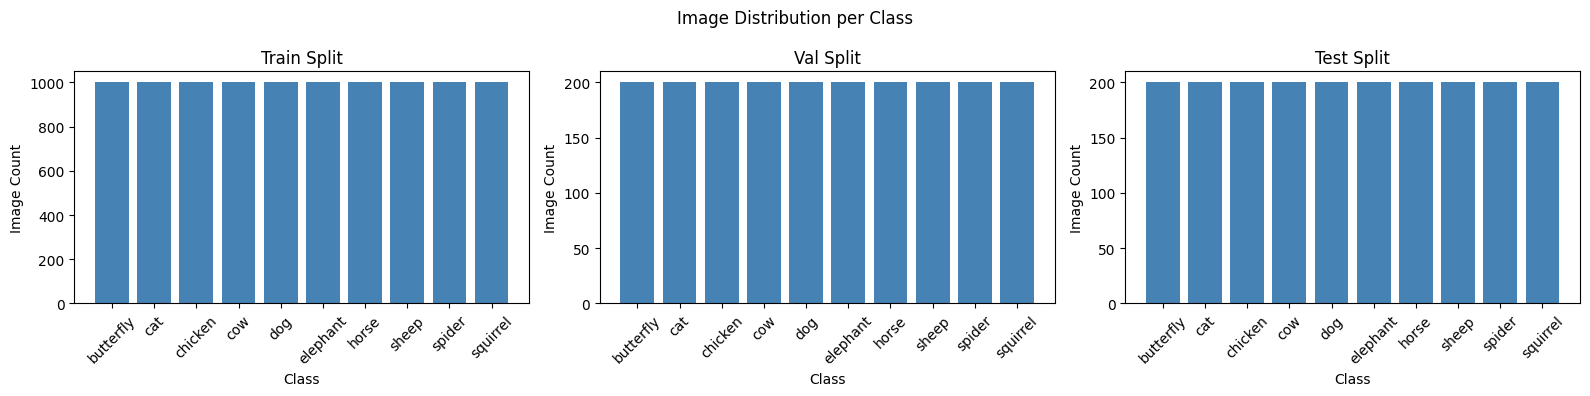

In [5]:
# Class distribution plots
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, split in zip(axes, SPLITS):
    values = [counts[split][class_name] for class_name in CLASS_NAMES]
    ax.bar(CLASS_NAMES, values, color="steelblue")
    ax.set_title(f"{split.capitalize()} Split")
    ax.set_xlabel("Class")
    ax.set_ylabel("Image Count")
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Image Distribution per Class")
plt.tight_layout()
plt.show()


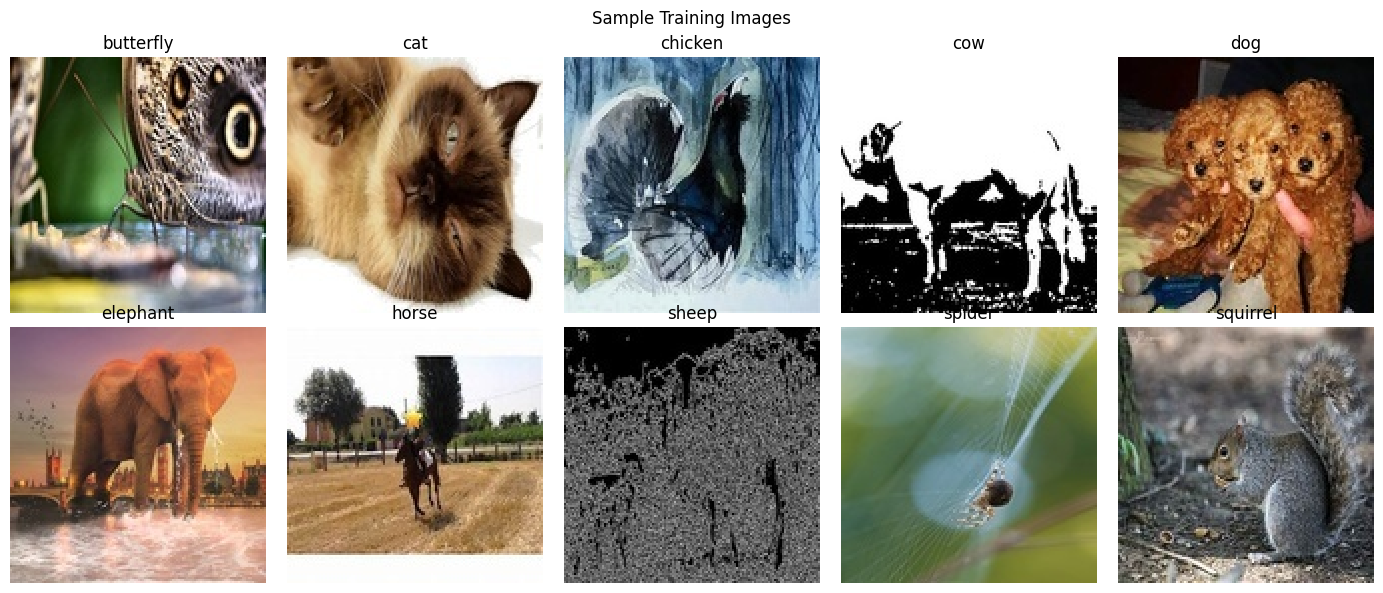

In [6]:
# Show one sample image from each class
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.flatten()

for i, class_name in enumerate(CLASS_NAMES):
    class_dir = DATA_DIR / "train" / class_name
    image_files = list(class_dir.glob("*.jpg")) + list(class_dir.glob("*.jpeg")) + list(class_dir.glob("*.png"))
    img = Image.open(image_files[0]).convert("RGB")
    img = img.resize(IMG_SIZE)
    axes[i].imshow(img)
    axes[i].set_title(class_name)
    axes[i].axis("off")

plt.suptitle("Sample Training Images")
plt.tight_layout()
plt.show()


### Preprocessing and Dataset Loading

Images are loaded with `image_dataset_from_directory`. The argument `pad_to_aspect_ratio=True` pads images where needed before resizing, so the final model input is always `128 x 128 x 3`. No data augmentation is included in the training dataset.


In [7]:
# Training dataset: original images only, no augmentation
train_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR / "train",
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    pad_to_aspect_ratio=True,
)


Found 10000 files belonging to 10 classes.


I0000 00:00:1778393101.453069      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778393101.459246      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [8]:
# Validation dataset: original images only
val_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR / "val",
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pad_to_aspect_ratio=True,
)


Found 2000 files belonging to 10 classes.


In [9]:
# Test dataset: original images only
# It is not shuffled because predictions must align with the true labels.
test_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR / "test",
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pad_to_aspect_ratio=True,
)


Found 2000 files belonging to 10 classes.


In [10]:
# Confirm batch shapes
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Pixel value range before model rescaling:", float(tf.reduce_min(images)), "to", float(tf.reduce_max(images)))


Image batch shape: (32, 128, 128, 3)
Label batch shape: (32,)
Pixel value range before model rescaling: 0.0 to 255.0


### Data Augmentation Demonstration Only

The next cell shows how augmentation changes sample images. These augmented images are only for visualization and are not used in model training.


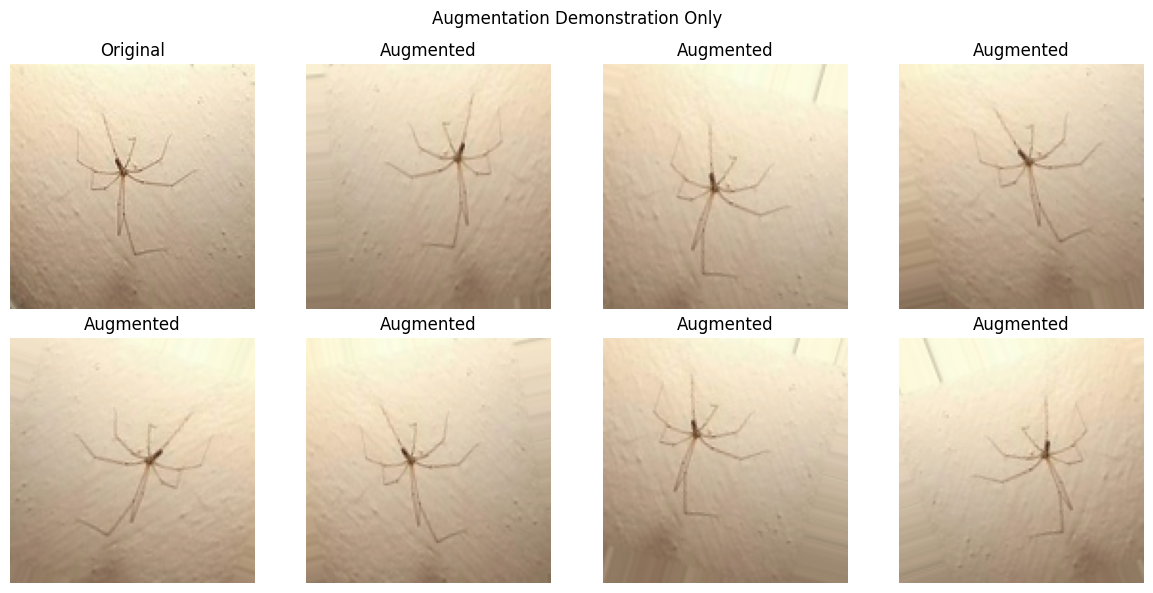

Training below uses only the original train_ds images.


In [11]:
# Augmentation demonstration only
for images, labels in train_ds.take(1):
    sample_image = images[0].numpy().astype("uint8")
    break

aug_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest",
)

aug_iterator = aug_datagen.flow(np.expand_dims(sample_image, axis=0), batch_size=1, shuffle=False, seed=SEED)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()
axes[0].imshow(sample_image)
axes[0].set_title("Original")
axes[0].axis("off")

for ax in axes[1:]:
    aug_img = next(aug_iterator)[0].astype("uint8")
    ax.imshow(aug_img)
    ax.set_title("Augmented")
    ax.axis("off")

plt.suptitle("Augmentation Demonstration Only")
plt.tight_layout()
plt.show()

print("Training below uses only the original train_ds images.")


---
## Section 2 - Baseline CNN Model

The baseline model has exactly three convolutional layers, each followed by pooling, then three fully connected layers and a softmax output layer.


In [12]:
# Build baseline CNN
baseline_model = models.Sequential(name="baseline_cnn")

baseline_model.add(layers.Input(shape=INPUT_SHAPE))
baseline_model.add(layers.Rescaling(1.0 / 255))

baseline_model.add(layers.Conv2D(32, (3, 3), activation="relu", padding="same"))
baseline_model.add(layers.MaxPooling2D((2, 2)))

baseline_model.add(layers.Conv2D(64, (3, 3), activation="relu", padding="same"))
baseline_model.add(layers.MaxPooling2D((2, 2)))

baseline_model.add(layers.Conv2D(128, (3, 3), activation="relu", padding="same"))
baseline_model.add(layers.MaxPooling2D((2, 2)))

baseline_model.add(layers.Flatten())
baseline_model.add(layers.Dense(256, activation="relu"))
baseline_model.add(layers.Dense(128, activation="relu"))
baseline_model.add(layers.Dense(64, activation="relu"))
baseline_model.add(layers.Dense(NUM_CLASSES, activation="softmax"))

baseline_model.summary()


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,523,914 (32.52 MB)

 Trainable params: 8,523,914 (32.52 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Compile baseline CNN
baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


In [14]:
# Train baseline CNN
t0_baseline = time.time()

history_baseline = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)],
    verbose=1,
)

baseline_time = time.time() - t0_baseline
print(f"Baseline training time: {baseline_time / 60:.2f} minutes")


Epoch 1/15


I0000 00:00:1778393107.899318     138 service.cc:152] XLA service 0x784370002ef0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778393107.899359     138 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778393107.899365     138 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778393108.345842     138 cuda_dnn.cc:529] Loaded cuDNN version 91002


  7/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.0938 - loss: 2.3228

I0000 00:00:1778393112.100550     138 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.1468 - loss: 2.2523 - val_accuracy: 0.3040 - val_loss: 1.9368
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.3354 - loss: 1.8735 - val_accuracy: 0.3950 - val_loss: 1.7223
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.4390 - loss: 1.6372 - val_accuracy: 0.4480 - val_loss: 1.6114
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.4880 - loss: 1.4905 - val_accuracy: 0.4610 - val_loss: 1.5630
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.5229 - loss: 1.3940 - val_accuracy: 0.4975 - val_loss: 1.4798
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.5686 - loss: 1.2758 - val_accuracy: 0.5115 - val_loss: 1.4430
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.5956 - loss: 1.1856 - val_accuracy: 0.4880 - val_loss: 1.4970
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.6328 - loss: 1.0997 - val_accuracy: 0.50

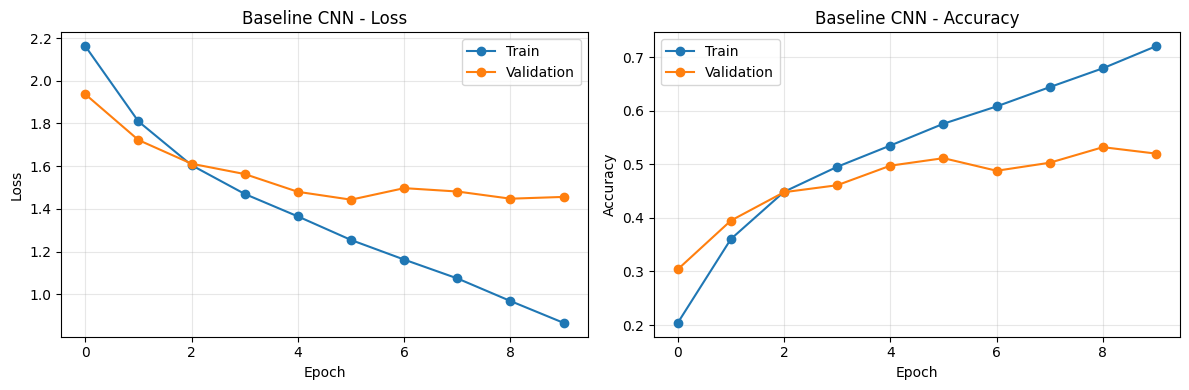

In [15]:
# Plot baseline training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_baseline.history["loss"], marker="o", label="Train")
axes[0].plot(history_baseline.history["val_loss"], marker="o", label="Validation")
axes[0].set_title("Baseline CNN - Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_baseline.history["accuracy"], marker="o", label="Train")
axes[1].plot(history_baseline.history["val_accuracy"], marker="o", label="Validation")
axes[1].set_title("Baseline CNN - Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [16]:
# Evaluate baseline CNN
loss_b, acc_b = baseline_model.evaluate(test_ds, verbose=0)
print(f"Baseline test loss: {loss_b:.4f}")
print(f"Baseline test accuracy: {acc_b:.4f}")

y_true = np.concatenate([labels.numpy() for images, labels in test_ds], axis=0)
y_pred_b = np.argmax(baseline_model.predict(test_ds, verbose=0), axis=1)

print("Classification Report - Baseline CNN")
print(classification_report(y_true, y_pred_b, target_names=CLASS_NAMES, digits=4))


Baseline test loss: 1.4555
Baseline test accuracy: 0.5105
Classification Report - Baseline CNN
              precision    recall  f1-score   support

   butterfly     0.6261    0.7200    0.6698       200
         cat     0.4471    0.3800    0.4108       200
     chicken     0.6940    0.4650    0.5569       200
         cow     0.4652    0.4350    0.4496       200
         dog     0.3440    0.4850    0.4025       200
    elephant     0.5344    0.6600    0.5906       200
       horse     0.4566    0.5000    0.4773       200
       sheep     0.4628    0.4350    0.4485       200
      spider     0.6755    0.6350    0.6546       200
    squirrel     0.5032    0.3900    0.4394       200

    accuracy                         0.5105      2000
   macro avg     0.5209    0.5105    0.5100      2000
weighted avg     0.5209    0.5105    0.5100      2000



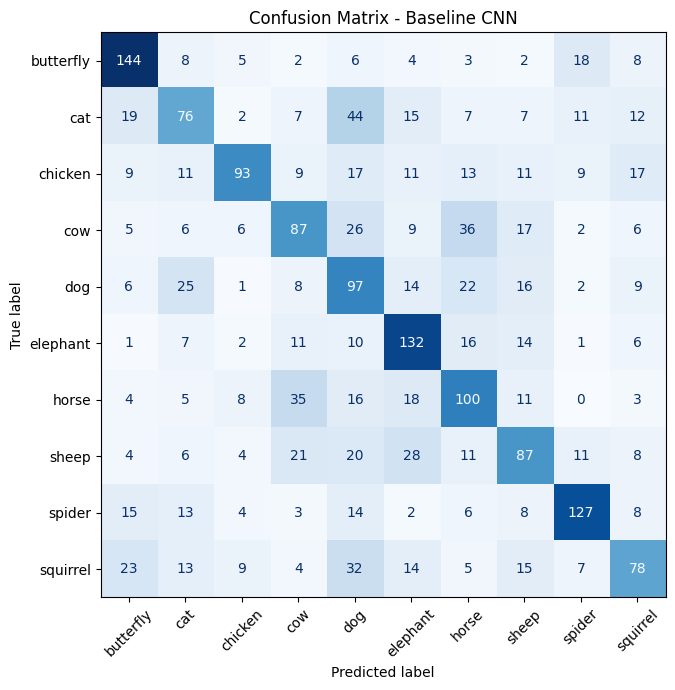

In [17]:
# Baseline confusion matrix
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay(
    confusion_matrix(y_true, y_pred_b),
    display_labels=CLASS_NAMES,
).plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
ax.set_title("Confusion Matrix - Baseline CNN")
plt.tight_layout()
plt.show()


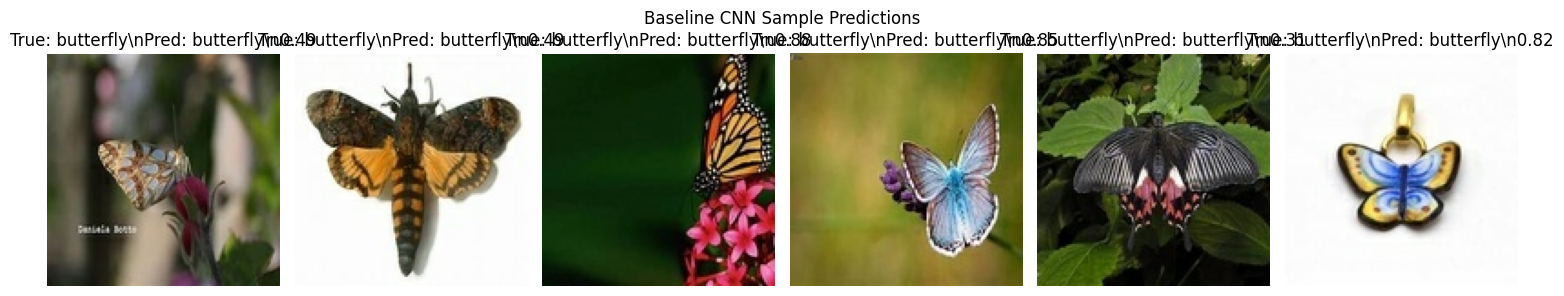

In [18]:
# Baseline inference on sample test images
for sample_images, sample_labels in test_ds.take(1):
    sample_probs = baseline_model.predict(sample_images, verbose=0)
    sample_preds = np.argmax(sample_probs, axis=1)
    break

fig, axes = plt.subplots(1, 6, figsize=(15, 3))

for i, ax in enumerate(axes):
    ax.imshow(sample_images[i].numpy().astype("uint8"))
    true_name = CLASS_NAMES[int(sample_labels[i])]
    pred_name = CLASS_NAMES[int(sample_preds[i])]
    confidence = float(sample_probs[i, sample_preds[i]])
    ax.set_title(f"True: {true_name}\\nPred: {pred_name}\\n{confidence:.2f}")
    ax.axis("off")

plt.suptitle("Baseline CNN Sample Predictions")
plt.tight_layout()
plt.show()


---
## Section 3 - Deeper CNN with Regularization

The deeper model doubles the baseline convolutional depth. It uses six convolutional layers, Batch Normalization and Dropout.


In [19]:
# Build deeper CNN with Adam
deeper_adam = models.Sequential(name="deeper_cnn_adam")

deeper_adam.add(layers.Input(shape=INPUT_SHAPE))
deeper_adam.add(layers.Rescaling(1.0 / 255))

deeper_adam.add(layers.Conv2D(32, (3, 3), padding="same", use_bias=False))
deeper_adam.add(layers.BatchNormalization())
deeper_adam.add(layers.Activation("relu"))
deeper_adam.add(layers.Conv2D(32, (3, 3), padding="same", use_bias=False))
deeper_adam.add(layers.BatchNormalization())
deeper_adam.add(layers.Activation("relu"))
deeper_adam.add(layers.MaxPooling2D((2, 2)))
deeper_adam.add(layers.Dropout(0.25))

deeper_adam.add(layers.Conv2D(64, (3, 3), padding="same", use_bias=False))
deeper_adam.add(layers.BatchNormalization())
deeper_adam.add(layers.Activation("relu"))
deeper_adam.add(layers.Conv2D(64, (3, 3), padding="same", use_bias=False))
deeper_adam.add(layers.BatchNormalization())
deeper_adam.add(layers.Activation("relu"))
deeper_adam.add(layers.MaxPooling2D((2, 2)))
deeper_adam.add(layers.Dropout(0.25))

deeper_adam.add(layers.Conv2D(128, (3, 3), padding="same", use_bias=False))
deeper_adam.add(layers.BatchNormalization())
deeper_adam.add(layers.Activation("relu"))
deeper_adam.add(layers.Conv2D(128, (3, 3), padding="same", use_bias=False))
deeper_adam.add(layers.BatchNormalization())
deeper_adam.add(layers.Activation("relu"))
deeper_adam.add(layers.MaxPooling2D((2, 2)))
deeper_adam.add(layers.Dropout(0.30))

deeper_adam.add(layers.Flatten())
deeper_adam.add(layers.Dense(512, activation="relu"))
deeper_adam.add(layers.BatchNormalization())
deeper_adam.add(layers.Dropout(0.50))
deeper_adam.add(layers.Dense(256, activation="relu"))
deeper_adam.add(layers.BatchNormalization())
deeper_adam.add(layers.Dropout(0.40))
deeper_adam.add(layers.Dense(128, activation="relu"))
deeper_adam.add(layers.Dropout(0.30))
deeper_adam.add(layers.Dense(NUM_CLASSES, activation="softmax"))

deeper_adam.summary()


Model: "deeper_cnn_adam"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 17,234,666 (65.75 MB)

 Trainable params: 17,232,234 (65.74 MB)

 Non-trainable params: 2,432 (9.50 KB)

In [20]:
# Compile deeper CNN with Adam
deeper_adam.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


In [21]:
# Train deeper CNN with Adam
t0_deeper_adam = time.time()

history_deeper_adam = deeper_adam.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
    verbose=1,
)

deeper_adam_time = time.time() - t0_deeper_adam
print(f"Deeper CNN Adam training time: {deeper_adam_time / 60:.2f} minutes")


Epoch 1/15


2026-05-10 06:06:37.719166: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 06:06:37.873749: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 06:06:39.249258: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 06:06:39.536191: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.1303 - loss: 3.0232

2026-05-10 06:07:05.397459: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 06:07:05.546948: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 06:07:06.343996: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 06:07:06.620033: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 94ms/step - accuracy: 0.1305 - loss: 3.0218 - val_accuracy: 0.1220 - val_loss: 2.7639
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.2199 - loss: 2.4684 - val_accuracy: 0.2380 - val_loss: 2.3162
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.2572 - loss: 2.2856 - val_accuracy: 0.2555 - val_loss: 2.2784
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.2908 - loss: 2.1342 - val_accuracy: 0.1530 - val_loss: 2.8978
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.3297 - loss: 1.9951 - val_accuracy: 0.2620 - val_loss: 2.3465
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.3554 - loss: 1.9066 - val_accuracy: 0.3215 - val_loss: 2.0693
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.3699 - loss: 1.8440 - val_accuracy: 0.3360 - val_loss: 1.9985
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.3967 - loss: 1.7545 - val_accurac

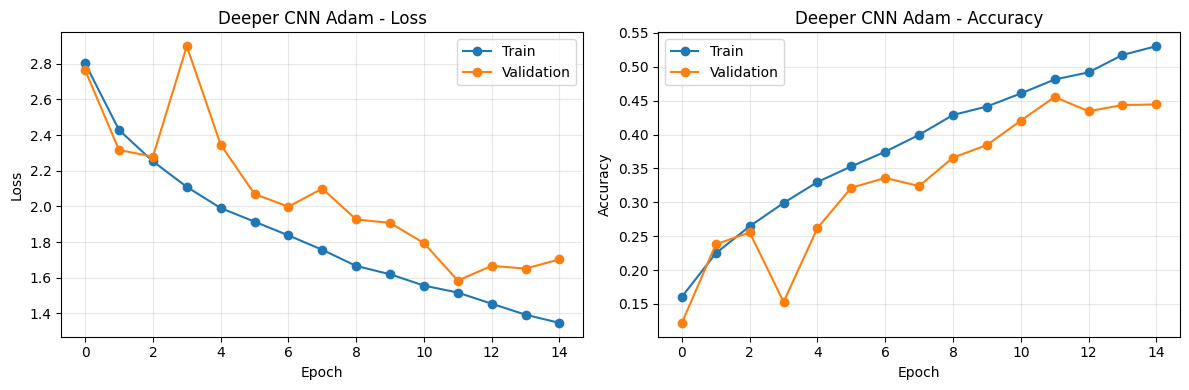

In [22]:
# Plot deeper Adam training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_deeper_adam.history["loss"], marker="o", label="Train")
axes[0].plot(history_deeper_adam.history["val_loss"], marker="o", label="Validation")
axes[0].set_title("Deeper CNN Adam - Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_deeper_adam.history["accuracy"], marker="o", label="Train")
axes[1].plot(history_deeper_adam.history["val_accuracy"], marker="o", label="Validation")
axes[1].set_title("Deeper CNN Adam - Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [23]:
# Evaluate deeper CNN with Adam
loss_da, acc_da = deeper_adam.evaluate(test_ds, verbose=0)
print(f"Deeper Adam test loss: {loss_da:.4f}")
print(f"Deeper Adam test accuracy: {acc_da:.4f}")

y_pred_da = np.argmax(deeper_adam.predict(test_ds, verbose=0), axis=1)

print("Classification Report - Deeper CNN Adam")
print(classification_report(y_true, y_pred_da, target_names=CLASS_NAMES, digits=4))


Deeper Adam test loss: 1.5846
Deeper Adam test accuracy: 0.4605
Classification Report - Deeper CNN Adam
              precision    recall  f1-score   support

   butterfly     0.9701    0.3250    0.4869       200
         cat     0.3625    0.6000    0.4520       200
     chicken     0.7864    0.4050    0.5347       200
         cow     0.5814    0.2500    0.3497       200
         dog     0.3424    0.3150    0.3281       200
    elephant     0.6135    0.6350    0.6241       200
       horse     0.6883    0.2650    0.3827       200
       sheep     0.3256    0.6300    0.4293       200
      spider     0.3823    0.8200    0.5215       200
    squirrel     0.5581    0.3600    0.4377       200

    accuracy                         0.4605      2000
   macro avg     0.5611    0.4605    0.4547      2000
weighted avg     0.5611    0.4605    0.4547      2000



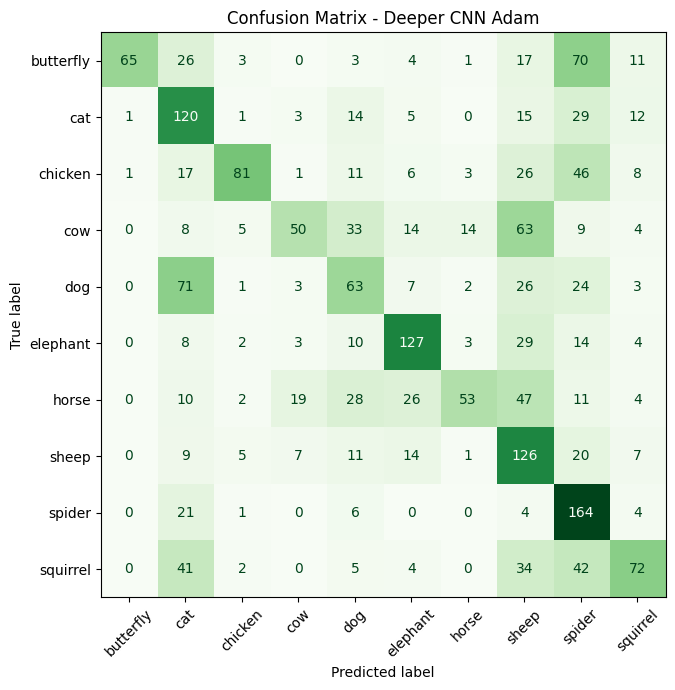

In [24]:
# Deeper Adam confusion matrix
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay(
    confusion_matrix(y_true, y_pred_da),
    display_labels=CLASS_NAMES,
).plot(ax=ax, cmap="Greens", colorbar=False, xticks_rotation=45)
ax.set_title("Confusion Matrix - Deeper CNN Adam")
plt.tight_layout()
plt.show()


---
## Section 4 - Optimizer Analysis: SGD vs Adam

The same deeper architecture is trained with SGD to compare convergence and final performance with Adam.


In [25]:
# Build deeper CNN with SGD
deeper_sgd = models.Sequential(name="deeper_cnn_sgd")

deeper_sgd.add(layers.Input(shape=INPUT_SHAPE))
deeper_sgd.add(layers.Rescaling(1.0 / 255))

deeper_sgd.add(layers.Conv2D(32, (3, 3), padding="same", use_bias=False))
deeper_sgd.add(layers.BatchNormalization())
deeper_sgd.add(layers.Activation("relu"))
deeper_sgd.add(layers.Conv2D(32, (3, 3), padding="same", use_bias=False))
deeper_sgd.add(layers.BatchNormalization())
deeper_sgd.add(layers.Activation("relu"))
deeper_sgd.add(layers.MaxPooling2D((2, 2)))
deeper_sgd.add(layers.Dropout(0.25))

deeper_sgd.add(layers.Conv2D(64, (3, 3), padding="same", use_bias=False))
deeper_sgd.add(layers.BatchNormalization())
deeper_sgd.add(layers.Activation("relu"))
deeper_sgd.add(layers.Conv2D(64, (3, 3), padding="same", use_bias=False))
deeper_sgd.add(layers.BatchNormalization())
deeper_sgd.add(layers.Activation("relu"))
deeper_sgd.add(layers.MaxPooling2D((2, 2)))
deeper_sgd.add(layers.Dropout(0.25))

deeper_sgd.add(layers.Conv2D(128, (3, 3), padding="same", use_bias=False))
deeper_sgd.add(layers.BatchNormalization())
deeper_sgd.add(layers.Activation("relu"))
deeper_sgd.add(layers.Conv2D(128, (3, 3), padding="same", use_bias=False))
deeper_sgd.add(layers.BatchNormalization())
deeper_sgd.add(layers.Activation("relu"))
deeper_sgd.add(layers.MaxPooling2D((2, 2)))
deeper_sgd.add(layers.Dropout(0.30))

deeper_sgd.add(layers.Flatten())
deeper_sgd.add(layers.Dense(512, activation="relu"))
deeper_sgd.add(layers.BatchNormalization())
deeper_sgd.add(layers.Dropout(0.50))
deeper_sgd.add(layers.Dense(256, activation="relu"))
deeper_sgd.add(layers.BatchNormalization())
deeper_sgd.add(layers.Dropout(0.40))
deeper_sgd.add(layers.Dense(128, activation="relu"))
deeper_sgd.add(layers.Dropout(0.30))
deeper_sgd.add(layers.Dense(NUM_CLASSES, activation="softmax"))

deeper_sgd.summary()


Model: "deeper_cnn_sgd"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 128, 128, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 64, 64, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 17,234,666 (65.75 MB)

 Trainable params: 17,232,234 (65.74 MB)

 Non-trainable params: 2,432 (9.50 KB)

In [26]:
# Compile deeper CNN with SGD
deeper_sgd.compile(
    optimizer=keras.optimizers.SGD(learning_rate=1e-2, momentum=0.9),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


In [27]:
# Train deeper CNN with SGD
t0_deeper_sgd = time.time()

history_deeper_sgd = deeper_sgd.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
    verbose=1,
)

deeper_sgd_time = time.time() - t0_deeper_sgd
print(f"Deeper CNN SGD training time: {deeper_sgd_time / 60:.2f} minutes")


Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 81ms/step - accuracy: 0.1363 - loss: 2.6473 - val_accuracy: 0.1675 - val_loss: 2.2390
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.2297 - loss: 2.1536 - val_accuracy: 0.2680 - val_loss: 2.0372
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.2880 - loss: 1.9831 - val_accuracy: 0.3360 - val_loss: 1.8685
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 56ms/step - accuracy: 0.3268 - loss: 1.8819 - val_accuracy: 0.3010 - val_loss: 2.2067
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.3681 - loss: 1.7688 - val_accuracy: 0.3105 - val_loss: 2.0989
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step - accuracy: 0.4075 - loss: 1.6575 - val_accuracy: 0.4005 - val_loss: 1.7184
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step - accuracy: 0.4456 - loss: 1.5672 - val_accuracy: 0.4790 - val_loss: 1.5187
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step - accuracy: 0.4859 - loss: 1.4515 - 

In [28]:
# Evaluate deeper CNN with SGD
loss_ds, acc_ds = deeper_sgd.evaluate(test_ds, verbose=0)
print(f"Deeper SGD test loss: {loss_ds:.4f}")
print(f"Deeper SGD test accuracy: {acc_ds:.4f}")

y_pred_ds = np.argmax(deeper_sgd.predict(test_ds, verbose=0), axis=1)

print("Classification Report - Deeper CNN SGD")
print(classification_report(y_true, y_pred_ds, target_names=CLASS_NAMES, digits=4))


Deeper SGD test loss: 1.3515
Deeper SGD test accuracy: 0.5405
Classification Report - Deeper CNN SGD
              precision    recall  f1-score   support

   butterfly     0.8248    0.5650    0.6706       200
         cat     0.4882    0.5150    0.5012       200
     chicken     0.7111    0.4800    0.5731       200
         cow     0.4314    0.5500    0.4835       200
         dog     0.5000    0.2550    0.3377       200
    elephant     0.5542    0.6650    0.6045       200
       horse     0.7236    0.4450    0.5511       200
       sheep     0.3428    0.6650    0.4524       200
      spider     0.7028    0.7450    0.7233       200
    squirrel     0.5279    0.5200    0.5239       200

    accuracy                         0.5405      2000
   macro avg     0.5807    0.5405    0.5421      2000
weighted avg     0.5807    0.5405    0.5421      2000



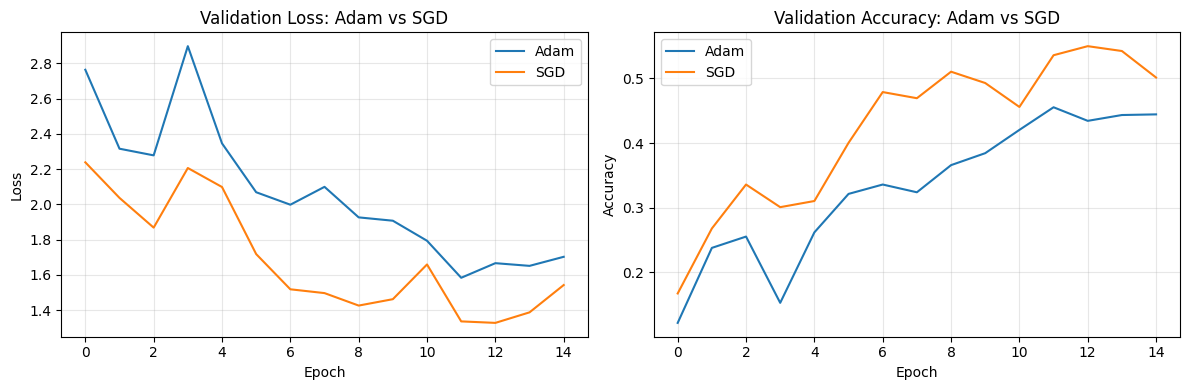

In [29]:
# Adam vs SGD validation curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_deeper_adam.history["val_loss"], label="Adam")
axes[0].plot(history_deeper_sgd.history["val_loss"], label="SGD")
axes[0].set_title("Validation Loss: Adam vs SGD")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_deeper_adam.history["val_accuracy"], label="Adam")
axes[1].plot(history_deeper_sgd.history["val_accuracy"], label="SGD")
axes[1].set_title("Validation Accuracy: Adam vs SGD")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


---
## Section 5 - Ablation Study: Removing Dropout

This model removes Dropout from the deeper CNN while keeping Batch Normalization. The goal is to observe how this affects overfitting and test performance.


In [30]:
# Build deeper CNN without Dropout
no_dropout = models.Sequential(name="deeper_cnn_no_dropout")

no_dropout.add(layers.Input(shape=INPUT_SHAPE))
no_dropout.add(layers.Rescaling(1.0 / 255))

no_dropout.add(layers.Conv2D(32, (3, 3), padding="same", use_bias=False))
no_dropout.add(layers.BatchNormalization())
no_dropout.add(layers.Activation("relu"))
no_dropout.add(layers.Conv2D(32, (3, 3), padding="same", use_bias=False))
no_dropout.add(layers.BatchNormalization())
no_dropout.add(layers.Activation("relu"))
no_dropout.add(layers.MaxPooling2D((2, 2)))

no_dropout.add(layers.Conv2D(64, (3, 3), padding="same", use_bias=False))
no_dropout.add(layers.BatchNormalization())
no_dropout.add(layers.Activation("relu"))
no_dropout.add(layers.Conv2D(64, (3, 3), padding="same", use_bias=False))
no_dropout.add(layers.BatchNormalization())
no_dropout.add(layers.Activation("relu"))
no_dropout.add(layers.MaxPooling2D((2, 2)))

no_dropout.add(layers.Conv2D(128, (3, 3), padding="same", use_bias=False))
no_dropout.add(layers.BatchNormalization())
no_dropout.add(layers.Activation("relu"))
no_dropout.add(layers.Conv2D(128, (3, 3), padding="same", use_bias=False))
no_dropout.add(layers.BatchNormalization())
no_dropout.add(layers.Activation("relu"))
no_dropout.add(layers.MaxPooling2D((2, 2)))

no_dropout.add(layers.Flatten())
no_dropout.add(layers.Dense(512, activation="relu"))
no_dropout.add(layers.BatchNormalization())
no_dropout.add(layers.Dense(256, activation="relu"))
no_dropout.add(layers.BatchNormalization())
no_dropout.add(layers.Dense(128, activation="relu"))
no_dropout.add(layers.Dense(NUM_CLASSES, activation="softmax"))

no_dropout.summary()


Model: "deeper_cnn_no_dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 128, 128, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 128, 128, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 64, 64, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 32, 32, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_17 (Activation)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 128)    │             

 Total params: 17,234,666 (65.75 MB)

 Trainable params: 17,232,234 (65.74 MB)

 Non-trainable params: 2,432 (9.50 KB)

In [31]:
# Compile and train no-dropout model
no_dropout.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

t0_no_dropout = time.time()

history_no_dropout = no_dropout.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)],
    verbose=1,
)

no_dropout_time = time.time() - t0_no_dropout
print(f"No-dropout training time: {no_dropout_time / 60:.2f} minutes")


Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 72ms/step - accuracy: 0.2984 - loss: 2.0639 - val_accuracy: 0.1710 - val_loss: 2.5132
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.5859 - loss: 1.2407 - val_accuracy: 0.4245 - val_loss: 1.6431
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.8064 - loss: 0.6689 - val_accuracy: 0.4910 - val_loss: 1.6021
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step - accuracy: 0.9566 - loss: 0.2392 - val_accuracy: 0.5440 - val_loss: 1.5105
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 56ms/step - accuracy: 0.9899 - loss: 0.0923 - val_accuracy: 0.5295 - val_loss: 1.5928
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step - accuracy: 0.9967 - loss: 0.0461 - val_accuracy: 0.5495 - val_loss: 1.5672
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step - accuracy: 0.9989 - loss: 0.0268 - val_accuracy: 0.4610 - val_loss: 2.0695
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step - accuracy: 0.9982 - loss: 0.0200 - 

In [32]:
# Evaluate no-dropout model
loss_nd, acc_nd = no_dropout.evaluate(test_ds, verbose=0)
print(f"No-dropout test loss: {loss_nd:.4f}")
print(f"No-dropout test accuracy: {acc_nd:.4f}")

y_pred_nd = np.argmax(no_dropout.predict(test_ds, verbose=0), axis=1)

print("Classification Report - Deeper CNN without Dropout")
print(classification_report(y_true, y_pred_nd, target_names=CLASS_NAMES, digits=4))


No-dropout test loss: 1.5699
No-dropout test accuracy: 0.5305
Classification Report - Deeper CNN without Dropout
              precision    recall  f1-score   support

   butterfly     0.7562    0.6050    0.6722       200
         cat     0.5227    0.5750    0.5476       200
     chicken     0.9118    0.3100    0.4627       200
         cow     0.4560    0.5700    0.5067       200
         dog     0.6125    0.2450    0.3500       200
    elephant     0.5605    0.6250    0.5910       200
       horse     0.6250    0.4750    0.5398       200
       sheep     0.5147    0.5250    0.5198       200
      spider     0.4916    0.7350    0.5892       200
    squirrel     0.3721    0.6400    0.4706       200

    accuracy                         0.5305      2000
   macro avg     0.5823    0.5305    0.5250      2000
weighted avg     0.5823    0.5305    0.5250      2000



---
## Section 6 - Comparative Analysis of Scratch Models

This section compares the baseline CNN, the deeper CNN with Adam, the deeper CNN with SGD and the ablation model without Dropout.


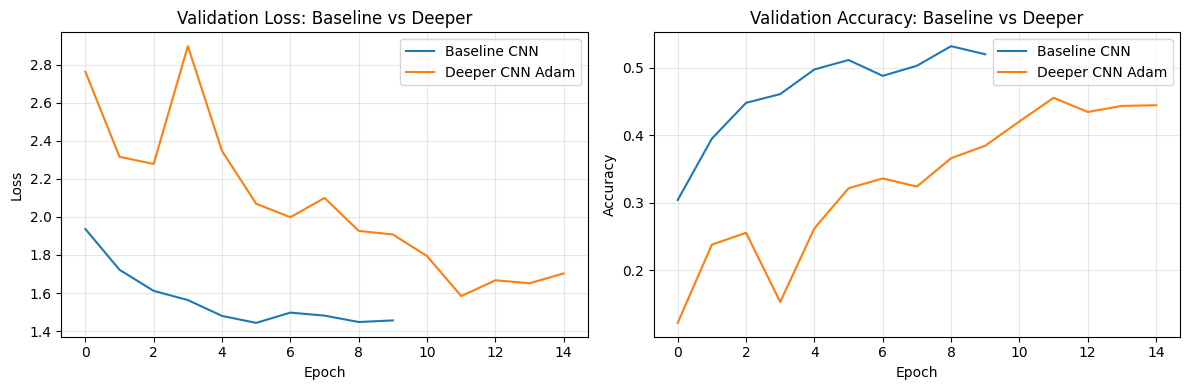

In [33]:
# Baseline vs deeper validation curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_baseline.history["val_loss"], label="Baseline CNN")
axes[0].plot(history_deeper_adam.history["val_loss"], label="Deeper CNN Adam")
axes[0].set_title("Validation Loss: Baseline vs Deeper")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_baseline.history["val_accuracy"], label="Baseline CNN")
axes[1].plot(history_deeper_adam.history["val_accuracy"], label="Deeper CNN Adam")
axes[1].set_title("Validation Accuracy: Baseline vs Deeper")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [34]:
# Scratch model comparison table
scratch_results = pd.DataFrame({
    "Model": ["Baseline CNN", "Deeper CNN Adam", "Deeper CNN SGD", "No Dropout"],
    "Test Accuracy": [acc_b, acc_da, acc_ds, acc_nd],
    "Test Loss": [loss_b, loss_da, loss_ds, loss_nd],
    "Training Time (min)": [baseline_time / 60, deeper_adam_time / 60, deeper_sgd_time / 60, no_dropout_time / 60],
})

display(scratch_results)


,Model,Test Accuracy,Test Loss,Training Time (min)
0,Baseline CNN,0.5105,1.455455,1.310308
1,Deeper CNN Adam,0.4605,1.584596,4.958748
2,Deeper CNN SGD,0.5405,1.351550,4.682532
3,No Dropout,0.5305,1.569945,2.555112


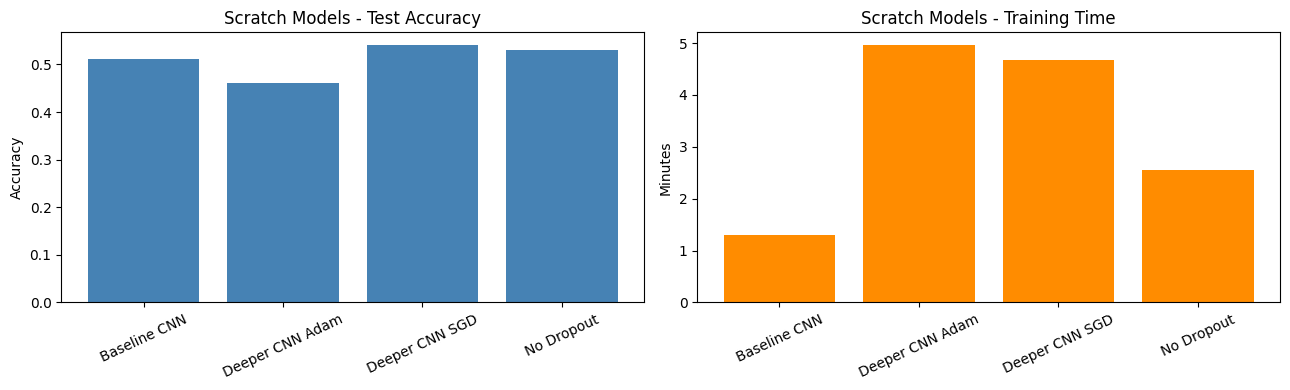

In [35]:
# Scratch model comparison plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(scratch_results["Model"], scratch_results["Test Accuracy"], color="steelblue")
axes[0].set_title("Scratch Models - Test Accuracy")
axes[0].set_ylabel("Accuracy")
axes[0].tick_params(axis="x", rotation=25)

axes[1].bar(scratch_results["Model"], scratch_results["Training Time (min)"], color="darkorange")
axes[1].set_title("Scratch Models - Training Time")
axes[1].set_ylabel("Minutes")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()


---
## Section 7 - Transfer Learning with ResNet50

ResNet50 is used as the pretrained model. The original ImageNet classifier is removed with `include_top=False`, and a new classifier head is added for the 10 animal classes.


In [36]:
# Load pretrained ResNet50 convolutional base
resnet_base = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=INPUT_SHAPE,
)

resnet_base.trainable = False
print("ResNet50 base loaded. Trainable:", resnet_base.trainable)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
ResNet50 base loaded. Trainable: False


In [37]:
# Build transfer learning model
resnet_model = models.Sequential(name="resnet50_transfer_learning")

resnet_model.add(layers.Input(shape=INPUT_SHAPE))
resnet_model.add(layers.Lambda(resnet_preprocess))
resnet_model.add(resnet_base)
resnet_model.add(layers.GlobalAveragePooling2D())
resnet_model.add(layers.Dense(256, activation="relu"))
resnet_model.add(layers.Dropout(0.50))
resnet_model.add(layers.Dense(NUM_CLASSES, activation="softmax"))

resnet_model.summary()


Model: "resnet50_transfer_learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [38]:
# Compile transfer learning model for feature extraction
resnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


In [39]:
# Train only the new classifier head
t0_resnet_head = time.time()

history_resnet_head = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)],
    verbose=1,
)

resnet_head_time = time.time() - t0_resnet_head
print(f"ResNet50 feature extraction time: {resnet_head_time / 60:.2f} minutes")


Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 71ms/step - accuracy: 0.4583 - loss: 2.0135 - val_accuracy: 0.8420 - val_loss: 0.4719
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.7892 - loss: 0.6555 - val_accuracy: 0.8655 - val_loss: 0.3890
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.8381 - loss: 0.4949 - val_accuracy: 0.8780 - val_loss: 0.3543
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.8668 - loss: 0.4005 - val_accuracy: 0.8805 - val_loss: 0.3340
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.8736 - loss: 0.3596 - val_accuracy: 0.8940 - val_loss: 0.3197
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.8931 - loss: 0.3093 - val_accuracy: 0.8990 - val_loss: 0.3071
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.9073 - loss: 0.2715 - val_accuracy: 0.9005 - val_loss: 0.2987
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.9222 - loss: 0.2254 - 

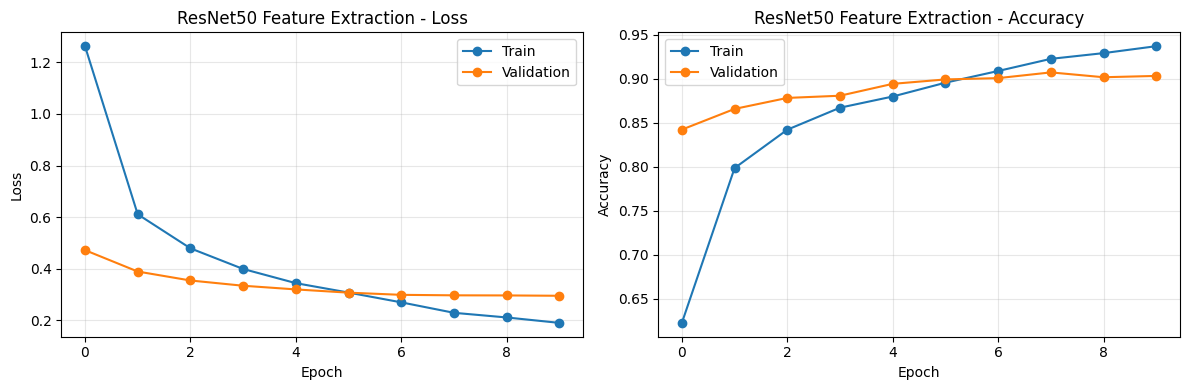

In [40]:
# Plot feature extraction curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_resnet_head.history["loss"], marker="o", label="Train")
axes[0].plot(history_resnet_head.history["val_loss"], marker="o", label="Validation")
axes[0].set_title("ResNet50 Feature Extraction - Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_resnet_head.history["accuracy"], marker="o", label="Train")
axes[1].plot(history_resnet_head.history["val_accuracy"], marker="o", label="Validation")
axes[1].set_title("ResNet50 Feature Extraction - Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Fine-tuning

Only the last ResNet block is unfrozen. A smaller learning rate is used for fine-tuning.


In [41]:
# Unfreeze only the last ResNet block
resnet_base.trainable = True

for layer in resnet_base.layers:
    layer.trainable = layer.name.startswith("conv5")

trainable_layers = sum([1 for layer in resnet_base.layers if layer.trainable])
print("Trainable layers in ResNet50 base:", trainable_layers)


Trainable layers in ResNet50 base: 32


In [42]:
# Compile model for fine-tuning
resnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


In [43]:
# Fine-tune ResNet50
t0_resnet_fine = time.time()

history_resnet_fine = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)],
    verbose=1,
)

resnet_fine_time = time.time() - t0_resnet_fine
resnet_total_time = resnet_head_time + resnet_fine_time
print(f"ResNet50 fine-tuning time: {resnet_fine_time / 60:.2f} minutes")
print(f"ResNet50 total training time: {resnet_total_time / 60:.2f} minutes")


Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 50s 102ms/step - accuracy: 0.8666 - loss: 0.4022 - val_accuracy: 0.9010 - val_loss: 0.3000
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.9290 - loss: 0.2330 - val_accuracy: 0.9005 - val_loss: 0.2898
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 62ms/step - accuracy: 0.9476 - loss: 0.1789 - val_accuracy: 0.9070 - val_loss: 0.2754
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - accuracy: 0.9630 - loss: 0.1279 - val_accuracy: 0.9050 - val_loss: 0.2729
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - accuracy: 0.9675 - loss: 0.1093 - val_accuracy: 0.9100 - val_loss: 0.2725
ResNet50 fine-tuning time: 2.13 minutes
ResNet50 total training time: 4.45 minutes


In [44]:
# Evaluate ResNet50 transfer learning model
loss_rn, acc_rn = resnet_model.evaluate(test_ds, verbose=0)
print(f"ResNet50 test loss: {loss_rn:.4f}")
print(f"ResNet50 test accuracy: {acc_rn:.4f}")

y_pred_rn = np.argmax(resnet_model.predict(test_ds, verbose=0), axis=1)

print("Classification Report - ResNet50 Transfer Learning")
print(classification_report(y_true, y_pred_rn, target_names=CLASS_NAMES, digits=4))


ResNet50 test loss: 0.3031
ResNet50 test accuracy: 0.9050
Classification Report - ResNet50 Transfer Learning
              precision    recall  f1-score   support

   butterfly     0.9543    0.9400    0.9471       200
         cat     0.8911    0.9000    0.8955       200
     chicken     0.9235    0.9050    0.9141       200
         cow     0.8382    0.8550    0.8465       200
         dog     0.9326    0.9000    0.9160       200
    elephant     0.9265    0.9450    0.9356       200
       horse     0.9036    0.8900    0.8967       200
       sheep     0.8374    0.8500    0.8437       200
      spider     0.9648    0.9600    0.9624       200
    squirrel     0.8829    0.9050    0.8938       200

    accuracy                         0.9050      2000
   macro avg     0.9055    0.9050    0.9052      2000
weighted avg     0.9055    0.9050    0.9052      2000



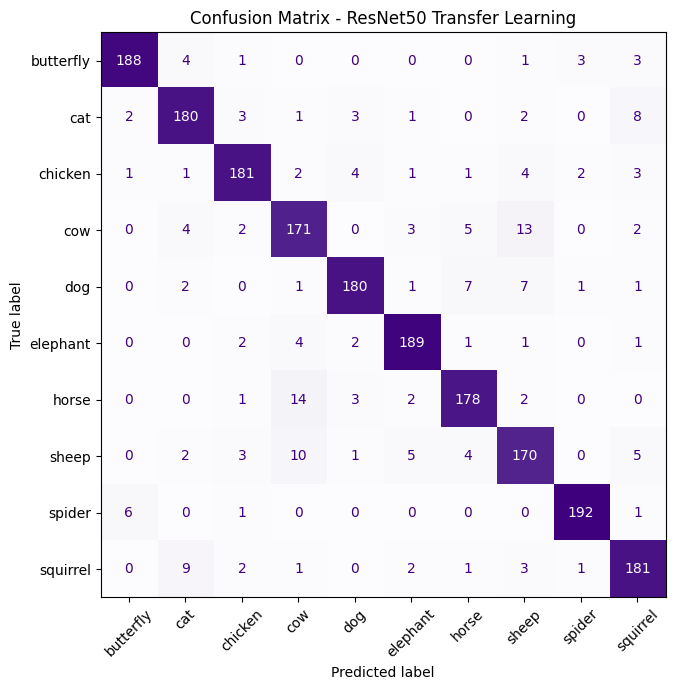

In [45]:
# ResNet50 confusion matrix
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay(
    confusion_matrix(y_true, y_pred_rn),
    display_labels=CLASS_NAMES,
).plot(ax=ax, cmap="Purples", colorbar=False, xticks_rotation=45)
ax.set_title("Confusion Matrix - ResNet50 Transfer Learning")
plt.tight_layout()
plt.show()


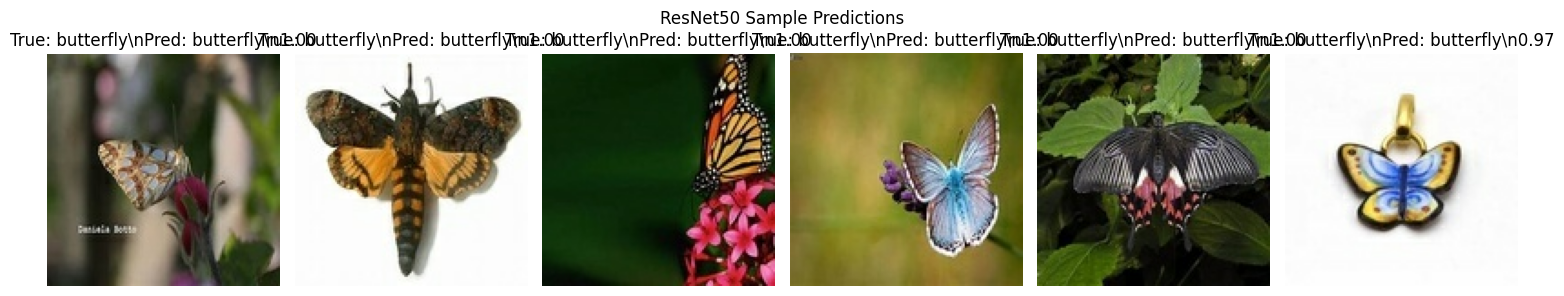

In [46]:
# ResNet50 sample predictions
for sample_images, sample_labels in test_ds.take(1):
    sample_probs = resnet_model.predict(sample_images, verbose=0)
    sample_preds = np.argmax(sample_probs, axis=1)
    break

fig, axes = plt.subplots(1, 6, figsize=(15, 3))

for i, ax in enumerate(axes):
    ax.imshow(sample_images[i].numpy().astype("uint8"))
    true_name = CLASS_NAMES[int(sample_labels[i])]
    pred_name = CLASS_NAMES[int(sample_preds[i])]
    confidence = float(sample_probs[i, sample_preds[i]])
    ax.set_title(f"True: {true_name}\\nPred: {pred_name}\\n{confidence:.2f}")
    ax.axis("off")

plt.suptitle("ResNet50 Sample Predictions")
plt.tight_layout()
plt.show()


---
## Section 8 - Final Model Comparison

This section compares the main scratch-trained models with the transfer learning model.


In [47]:
# Final comparison table
final_results = pd.DataFrame({
    "Model": ["Baseline CNN", "Deeper CNN Adam", "Deeper CNN SGD", "ResNet50 Transfer Learning"],
    "Test Accuracy": [acc_b, acc_da, acc_ds, acc_rn],
    "Test Loss": [loss_b, loss_da, loss_ds, loss_rn],
    "Training Time (min)": [baseline_time / 60, deeper_adam_time / 60, deeper_sgd_time / 60, resnet_total_time / 60],
})

display(final_results)


,Model,Test Accuracy,Test Loss,Training Time (min)
0,Baseline CNN,0.5105,1.455455,1.310308
1,Deeper CNN Adam,0.4605,1.584596,4.958748
2,Deeper CNN SGD,0.5405,1.351550,4.682532
3,ResNet50 Transfer Learning,0.9050,0.303146,4.454384


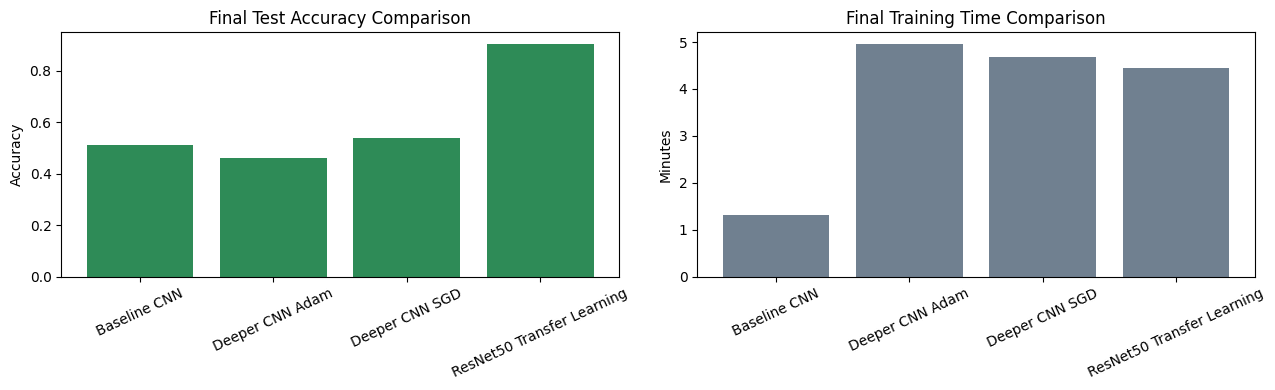

In [48]:
# Final comparison plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(final_results["Model"], final_results["Test Accuracy"], color="seagreen")
axes[0].set_title("Final Test Accuracy Comparison")
axes[0].set_ylabel("Accuracy")
axes[0].tick_params(axis="x", rotation=25)

axes[1].bar(final_results["Model"], final_results["Training Time (min)"], color="slategray")
axes[1].set_title("Final Training Time Comparison")
axes[1].set_ylabel("Minutes")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()
